<a href="https://colab.research.google.com/github/Joydas2003/Electrical-Load-Forcasting-Ml/blob/master/Machine%20Learning%20Based%20short%20term%20Electrical%20Load%20Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
pgcb_df=pd.read_csv( "/content/drive/MyDrive/Load Forcasting/PGCB_date_power_demand.csv")
nasa_df=pd.read_csv("/content/drive/MyDrive/Load Forcasting/Hourly_Temp_Humidity (2).csv")
from IPython.display import display

display(pgcb_df)
display(nasa_df)

Mounted at /content/drive


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks
0,4/19/2015 22:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,4/19/2015 21:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,4/19/2015 19:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,4/19/2015 18:30,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,4/19/2015 18:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,6/17/2025 4:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,6/17/2025 3:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,6/17/2025 2:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,6/17/2025 1:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


,datetime,Temperature_C,Humidity_%
0,2015-01-19 00:00:00,13.79,66.79
1,2015-01-19 01:00:00,13.25,69.37
2,2015-01-19 02:00:00,12.73,72.19
3,2015-01-19 03:00:00,12.21,75.48
4,2015-01-19 04:00:00,11.78,78.84
...,...,...,...
91267,2025-06-17 19:00:00,26.98,95.39
91268,2025-06-17 20:00:00,26.81,96.40
91269,2025-06-17 21:00:00,26.70,96.67
91270,2025-06-17 22:00:00,26.61,96.64


In [3]:
# Date column গুলো ensure করা datetime format এ আছে
pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
nasa_df['datetime'] = pd.to_datetime(nasa_df['datetime'])

# Merge করা, left join করলে সব PGCB date থাকবে
df = pd.merge(pgcb_df, nasa_df, on='datetime', how='left')

# Display
from IPython.display import display
display(df)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,26.87,96.23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

Convert the column datatype to datetime format.

In [5]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

In [6]:
df=df.set_index("datetime")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


In [7]:
df.index=pd.to_datetime(df.index)
df=df.sort_index()
df = df.loc['2020-06-17':'2025-06-17']
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,10574.0,10574,0,5967,2653,773,96,0.0,NaN,945,146,NaN,NaN,NaN,26.99,96.66
2020-06-17 01:00:00,9974.0,9974,0,6106,1919,774,96,0.0,NaN,945,144,NaN,NaN,NaN,26.91,96.71
2020-06-17 02:00:00,9866.0,9866,0,6125,1796,776,96,0.0,NaN,945,138,NaN,NaN,NaN,26.92,96.69
2020-06-17 03:00:00,9538.0,9538,0,6111,1489,774,97,0.0,NaN,945,132,NaN,NaN,NaN,27.05,96.52
2020-06-17 04:00:00,9365.0,9365,0,6014,1415,774,97,0.0,NaN,945,130,NaN,NaN,NaN,27.16,96.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [8]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,Temperature_C,Humidity_%
count,4.566600e+04,45666.000000,45666.000000,45666.000000,4.566600e+04,45666.000000,45666.000000,45666.000000,18676.000000,45666.000000,45666.000000,7338.000000,5351.000000,43843.000000,43843.000000
mean,1.172725e+04,10486.425941,160.854290,5359.265186,2.625494e+03,1776.549490,87.523716,68.938529,9.233133,814.932992,102.714821,881.196375,0.546814,25.648235,78.100467
std,3.019141e+05,2631.330771,408.299264,1059.127972,1.367477e+05,1324.207897,69.990617,125.470828,16.272517,165.805138,39.878814,369.905673,4.525897,5.501353,18.457896
min,5.710000e+02,143.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.150000,17.050000
25%,8.734625e+03,8760.000000,0.000000,4668.000000,8.890000e+02,630.000000,40.000000,0.000000,0.000000,731.000000,76.000000,702.000000,0.000000,22.475000,67.520000
50%,1.034100e+04,10420.000000,0.000000,5377.000000,1.802000e+03,1250.000000,70.000000,0.000000,4.000000,898.000000,104.000000,822.000000,0.000000,26.800000,82.550000
75%,1.192900e+04,12200.000000,85.000000,6021.000000,2.895000e+03,2914.000000,127.000000,83.000000,13.000000,922.000000,130.000000,1050.750000,0.000000,29.200000,94.020000
max,6.452650e+07,156050.000000,13800.000000,66662.000000,2.922290e+07,31687.000000,4860.000000,2998.000000,922.000000,9410.000000,1565.000000,12665.000000,38.000000,42.700000,100.000000


Check the missing values

In [9]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,26990
india_bheramara_hvdc,0


To show the records that contain any null values

In [10]:
df[df.isna().any(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,10574.0,10574,0,5967,2653,773,96,0.0,NaN,945,146,NaN,NaN,NaN,26.99,96.66
2020-06-17 01:00:00,9974.0,9974,0,6106,1919,774,96,0.0,NaN,945,144,NaN,NaN,NaN,26.91,96.71
2020-06-17 02:00:00,9866.0,9866,0,6125,1796,776,96,0.0,NaN,945,138,NaN,NaN,NaN,26.92,96.69
2020-06-17 03:00:00,9538.0,9538,0,6111,1489,774,97,0.0,NaN,945,132,NaN,NaN,NaN,27.05,96.52
2020-06-17 04:00:00,9365.0,9365,0,6014,1415,774,97,0.0,NaN,945,130,NaN,NaN,NaN,27.16,96.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 07:00:00,11745.0,11745,0,5614,494,3487,132,128.0,28.0,924,26,874.0,38.0,NaN,28.00,91.76
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07


To show the records that contain all null values

In [11]:
df[df.isna().all(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,


Drop those rows that contain all missing values

In [12]:
df=df.dropna(how="all")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,10574.0,10574,0,5967,2653,773,96,0.0,NaN,945,146,NaN,NaN,NaN,26.99,96.66
2020-06-17 01:00:00,9974.0,9974,0,6106,1919,774,96,0.0,NaN,945,144,NaN,NaN,NaN,26.91,96.71
2020-06-17 02:00:00,9866.0,9866,0,6125,1796,776,96,0.0,NaN,945,138,NaN,NaN,NaN,26.92,96.69
2020-06-17 03:00:00,9538.0,9538,0,6111,1489,774,97,0.0,NaN,945,132,NaN,NaN,NaN,27.05,96.52
2020-06-17 04:00:00,9365.0,9365,0,6014,1415,774,97,0.0,NaN,945,130,NaN,NaN,NaN,27.16,96.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


Backwaer Fill -bfill

Forward Fill -ffill

In [13]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,10574.0,10574,0,5967,2653,773,96,0.0,NaN,945,146,NaN,NaN,NaN,26.99,96.66
2020-06-17 01:00:00,9974.0,9974,0,6106,1919,774,96,0.0,NaN,945,144,NaN,NaN,NaN,26.91,96.71
2020-06-17 02:00:00,9866.0,9866,0,6125,1796,776,96,0.0,NaN,945,138,NaN,NaN,NaN,26.92,96.69
2020-06-17 03:00:00,9538.0,9538,0,6111,1489,774,97,0.0,NaN,945,132,NaN,NaN,NaN,27.05,96.52
2020-06-17 04:00:00,9365.0,9365,0,6014,1415,774,97,0.0,NaN,945,130,NaN,NaN,NaN,27.16,96.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [14]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [15]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [16]:
cols = [
 'demand_mw', 'generation_mw',
 'gas', 'coal', 'hydro',
 'solar', 'wind', 'liquid_fuel',
 'india_bheramara_hvdc','Temperature_C','Humidity_%'
]
df[cols] = df[cols].interpolate(method='time')
df[cols] = df[cols].ffill().bfill()
df


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,10574.0,10574,0,5967,2653,773,96,0.0,3.0,945,146,NaN,NaN,NaN,26.99,96.66
2020-06-17 01:00:00,9974.0,9974,0,6106,1919,774,96,0.0,3.0,945,144,NaN,NaN,NaN,26.91,96.71
2020-06-17 02:00:00,9866.0,9866,0,6125,1796,776,96,0.0,3.0,945,138,NaN,NaN,NaN,26.92,96.69
2020-06-17 03:00:00,9538.0,9538,0,6111,1489,774,97,0.0,3.0,945,132,NaN,NaN,NaN,27.05,96.52
2020-06-17 04:00:00,9365.0,9365,0,6014,1415,774,97,0.0,3.0,945,130,NaN,NaN,NaN,27.16,96.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [17]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [18]:
df.isna().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,0
india_bheramara_hvdc,0


create the quarter column in the dataset

Feature Engineering

In [19]:
df.insert(0,"hour",df.index.hour)
df.insert(2,'month',df.index.month)
df.insert(3,'year',df.index.year)
df['day_of_week'] = df.index.dayofweek

# Month (yearly cycle)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend
datetime,,,,,,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,0,10574.0,6,2020,10574,0,5967,2653,773,96,...,146,NaN,NaN,NaN,26.99,96.66,2,1.224647e-16,-1.0,0
2020-06-17 01:00:00,1,9974.0,6,2020,9974,0,6106,1919,774,96,...,144,NaN,NaN,NaN,26.91,96.71,2,1.224647e-16,-1.0,0
2020-06-17 02:00:00,2,9866.0,6,2020,9866,0,6125,1796,776,96,...,138,NaN,NaN,NaN,26.92,96.69,2,1.224647e-16,-1.0,0
2020-06-17 03:00:00,3,9538.0,6,2020,9538,0,6111,1489,774,97,...,132,NaN,NaN,NaN,27.05,96.52,2,1.224647e-16,-1.0,0
2020-06-17 04:00:00,4,9365.0,6,2020,9365,0,6014,1415,774,97,...,130,NaN,NaN,NaN,27.16,96.47,2,1.224647e-16,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,...,24,864.0,38.0,NaN,28.74,87.73,1,1.224647e-16,-1.0,0
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,...,24,866.0,38.0,NaN,29.37,84.07,1,1.224647e-16,-1.0,0
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,...,26,985.0,38.0,NaN,29.77,81.71,1,1.224647e-16,-1.0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45666 entries, 2020-06-17 00:00:00 to 2025-06-17 12:00:00
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour                    45666 non-null  int32  
 1   generation_mw           45666 non-null  float64
 2   month                   45666 non-null  int32  
 3   year                    45666 non-null  int32  
 4   demand_mw               45666 non-null  int64  
 5   load_shedding           45666 non-null  int64  
 6   gas                     45666 non-null  int64  
 7   liquid_fuel             45666 non-null  int64  
 8   coal                    45666 non-null  int64  
 9   hydro                   45666 non-null  int64  
 10  solar                   45666 non-null  float64
 11  wind                    45666 non-null  float64
 12  india_bheramara_hvdc    45666 non-null  int64  
 13  india_bheramara_hvdc.1  45666 non-null  int64  
 14  ind

Laged Features : These are the past values of a time series data.

Use- past demand values are strong predictors.They can be used as input to predict future values.

In [21]:
#Demand from the same hour yesterday, same hour last week.
df['Demand_lag_24hr']=df["demand_mw"].shift(24)
df['Demand_lag_168hr']=df["demand_mw"].shift(168) #24*7=168 hour for week shift
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,0,10574.0,6,2020,10574,0,5967,2653,773,96,...,NaN,NaN,26.99,96.66,2,1.224647e-16,-1.0,0,NaN,NaN
2020-06-17 01:00:00,1,9974.0,6,2020,9974,0,6106,1919,774,96,...,NaN,NaN,26.91,96.71,2,1.224647e-16,-1.0,0,NaN,NaN
2020-06-17 02:00:00,2,9866.0,6,2020,9866,0,6125,1796,776,96,...,NaN,NaN,26.92,96.69,2,1.224647e-16,-1.0,0,NaN,NaN
2020-06-17 03:00:00,3,9538.0,6,2020,9538,0,6111,1489,774,97,...,NaN,NaN,27.05,96.52,2,1.224647e-16,-1.0,0,NaN,NaN
2020-06-17 04:00:00,4,9365.0,6,2020,9365,0,6014,1415,774,97,...,NaN,NaN,27.16,96.47,2,1.224647e-16,-1.0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,...,38.0,NaN,28.74,87.73,1,1.224647e-16,-1.0,0,13155.0,12403.0
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,...,38.0,NaN,29.37,84.07,1,1.224647e-16,-1.0,0,13569.0,12072.0
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,...,38.0,NaN,29.77,81.71,1,1.224647e-16,-1.0,0,13816.0,11377.0


In [22]:
#Rolling Mean and rolling standard deviation
df["demand_rolling_mean_24hr"]=df["demand_mw"].rolling(window=24).mean()

In [23]:
df["demand_rolling_mean_48hr"] = df["demand_mw"].rolling(window=48).mean()

In [24]:
df["demand_ema_24hr"] = df["demand_mw"].ewm(span=24, adjust=False).mean()

In [25]:
df["temp_rolling_mean_24hr"] = df["Temperature_C"].rolling(24).mean()
df['coal_share'] = df['coal'] / df['generation_mw']

In [26]:
# Non-renewable sources
gas = df['gas'].sum()
liquid_fuel = df['liquid_fuel'].sum()
coal = df['coal'].sum()

# Renewable sources (combine)
renewable = df[['hydro','solar','wind']].sum().sum()

# India import combine
india_import = df[['india_bheramara_hvdc',
                   'india_bheramara_hvdc.1',
                   'india_bheramara_hvdc.2',
                   'india_bheramara_hvdc.3']].sum().sum()

# Create dictionary
energy_sources = {
    'Gas': gas,
    'Liquid Fuel': liquid_fuel,
    'Coal': coal,
    'Renewable (Hydro+Solar+Wind)': renewable,
    'India Import': india_import
}

# Convert to pandas series
source_generation = pd.Series(energy_sources)

# Total generation
total_generation = source_generation.sum()

# Percentage
source_percent = (source_generation / total_generation) * 100

print(source_percent)

Gas                             48.797717
Liquid Fuel                     23.905909
Coal                            16.176016
Renewable (Hydro+Solar+Wind)     1.475022
India Import                     9.645335
dtype: float64


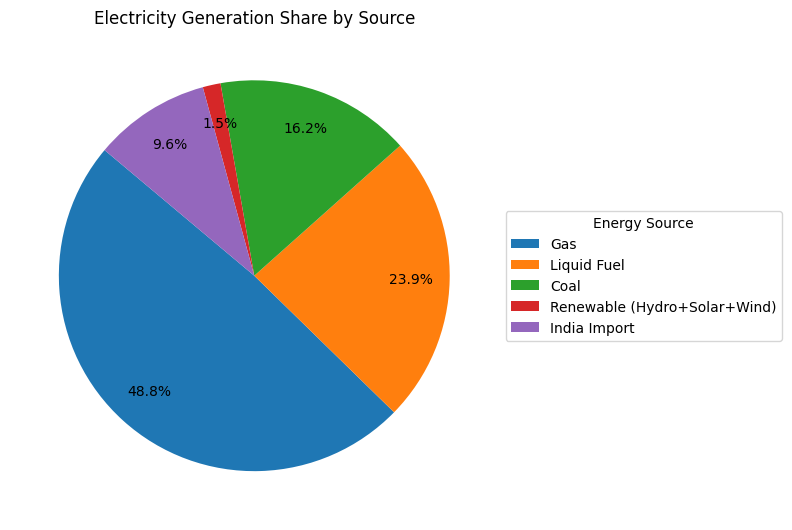

In [27]:

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    source_percent.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)

# legend use instead of labels on pie
plt.legend(
    wedges,
    source_percent.index,
    title="Energy Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Electricity Generation Share by Source")

plt.tight_layout()
plt.show()

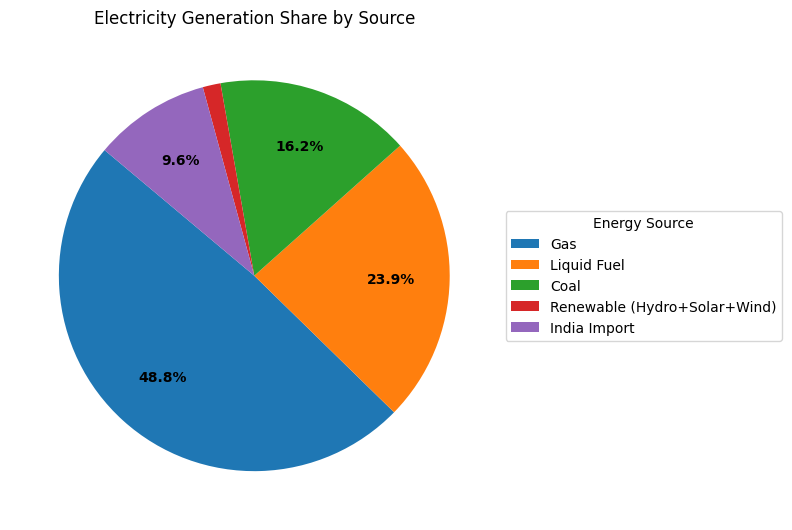

In [28]:

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    source_percent.values,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',  # ছোট % hide
    startangle=140,
    pctdistance=0.7,  # percentage ভিতরে রাখা
    textprops={'fontsize': 10}
)

# Percentage text style
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')

# Legend (clean look)
plt.legend(
    wedges,
    source_percent.index,
    title="Energy Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Electricity Generation Share by Source")

plt.tight_layout()
plt.show()

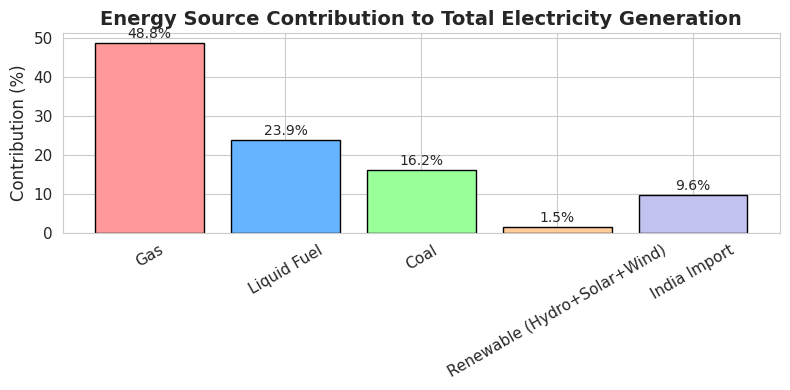

In [29]:

# Set style
sns.set_style("whitegrid")

plt.figure(figsize=(8,4))

# Custom colors (renewable highlighted)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']  # Gas, Liquid, Coal, Renewable, India Import

bars = plt.bar(
    source_percent.index,
    source_percent.values,
    color=colors,
    edgecolor='black'
)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,  # small gap
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Labels and title
plt.ylabel('Contribution (%)', fontsize=12)
plt.title('Energy Source Contribution to Total Electricity Generation', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['hour', 'generation_mw', 'month', 'year', 'demand_mw', 'load_shedding',
       'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind',
       'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
       'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3', 'remarks',
       'Temperature_C', 'Humidity_%', 'day_of_week', 'month_sin', 'month_cos',
       'is_weekend', 'Demand_lag_24hr', 'Demand_lag_168hr',
       'demand_rolling_mean_24hr', 'demand_rolling_mean_48hr',
       'demand_ema_24hr', 'temp_rolling_mean_24hr', 'coal_share'],
      dtype='object')

In [31]:
cols_to_drop = [
     'load_shedding','liquid_fuel',
    'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
    'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3',
    'remarks','liquid_fuel','hydro','solar','wind'
]

df.drop(columns=cols_to_drop, inplace=True)
df


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,,
2020-06-17 00:00:00,0,10574.0,6,2020,10574,5967,773,26.99,96.66,2,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10574.000000,NaN,0.073104
2020-06-17 01:00:00,1,9974.0,6,2020,9974,6106,774,26.91,96.71,2,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10526.000000,NaN,0.077602
2020-06-17 02:00:00,2,9866.0,6,2020,9866,6125,776,26.92,96.69,2,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10473.200000,NaN,0.078654
2020-06-17 03:00:00,3,9538.0,6,2020,9538,6111,774,27.05,96.52,2,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10398.384000,NaN,0.081149
2020-06-17 04:00:00,4,9365.0,6,2020,9365,6014,774,27.16,96.47,2,1.224647e-16,-1.0,0,NaN,NaN,NaN,NaN,10315.713280,NaN,0.082648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,87.73,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,84.07,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,81.71,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [32]:
df=df.dropna()
df

,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,,
2020-06-23 18:00:00,18,9862.0,6,2020,9862,5640,149,28.82,92.670,1,1.224647e-16,-1.0,0,10939.0,10574.0,9978.833333,9748.583333,9668.077191,28.864583,0.015108
2020-06-23 18:30:00,18,11298.0,6,2020,11298,6072,149,28.48,93.445,1,1.224647e-16,-1.0,0,11153.0,9974.0,9984.875000,9752.916667,9798.471016,28.891250,0.013188
2020-06-23 19:00:00,19,11577.0,6,2020,11577,6024,149,28.14,94.220,1,1.224647e-16,-1.0,0,11476.0,9866.0,9989.083333,9767.520833,9940.753335,28.914167,0.012870
2020-06-23 20:00:00,20,11673.0,6,2020,11673,6027,149,27.78,94.910,1,1.224647e-16,-1.0,0,11501.0,9538.0,9996.250000,9785.666667,10079.333068,28.932083,0.012764
2020-06-23 21:00:00,21,11693.0,6,2020,11693,6030,149,27.50,95.630,1,1.224647e-16,-1.0,0,11465.0,9365.0,10005.750000,9806.541667,10208.426423,28.946667,0.012743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,87.730,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,84.070,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,81.710,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [33]:
df['demand_mw'].describe()


,demand_mw
count,45498.000000
mean,10490.936305
std,2634.352634
min,143.000000
25%,8762.000000
50%,10426.000000
75%,12200.000000
max,156050.000000


In [34]:
df[df['demand_mw'] > 18000]


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,,
2023-02-11 18:30:00,18,10052.0,2,2023,104860,4369,1594,22.145,57.490,5,0.866025,0.500000,1,9531.0,6980.0,12544.166667,10457.250000,16541.156105,21.995625,0.158575
2023-04-18 18:30:00,18,15172.0,4,2023,156050,6423,2197,30.810,63.655,1,0.866025,-0.500000,0,15900.0,12911.0,20525.875000,17583.770833,25849.727575,30.694167,0.144806
2023-10-04 09:00:00,9,10587.0,10,2023,20587,5234,3221,27.290,91.420,2,-0.866025,0.500000,0,11779.0,12650.0,12126.625000,12337.250000,12227.818002,27.321250,0.304241
2023-10-11 03:00:00,3,11468.0,10,2023,117000,6021,2965,26.300,84.700,2,-0.866025,0.500000,0,11420.0,10439.0,16801.833333,14554.479167,21049.706911,29.248125,0.258546
2024-04-16 07:00:00,7,11701.0,4,2024,121000,6742,2979,28.270,70.840,1,0.866025,-0.500000,0,11250.0,11416.0,17028.958333,14411.145833,20901.542475,31.497292,0.254594
2024-07-03 05:00:00,5,11080.0,7,2024,111140,5265,3774,26.700,96.650,2,-0.500000,-0.866025,0,11180.0,14200.0,16618.125000,14682.187500,20447.693050,28.504583,0.340614


In [35]:

# Single-cell: Replace outliers

# Calculate IQR (optional for analysis)
Q1 = df['demand_mw'].quantile(0.25)
Q3 = df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

# Replace extreme values without deleting rows
df['demand_mw'] = df['demand_mw'].clip(lower=6000, upper=18000)

/tmp/ipykernel_660/1914990646.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_mw'] = df['demand_mw'].clip(lower=6000, upper=18000)


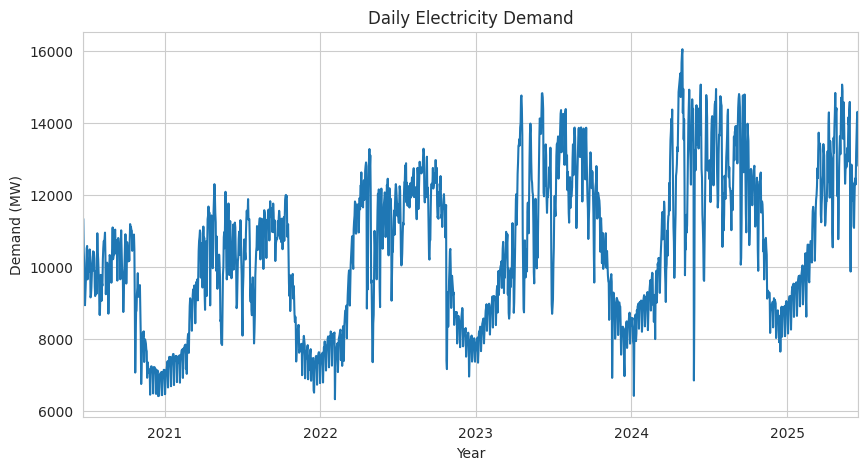

In [36]:
# Daily average demand
df_daily = df['demand_mw'].resample('D').mean().interpolate()

df_daily.plot(figsize=(10,5), title="Daily Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.show()


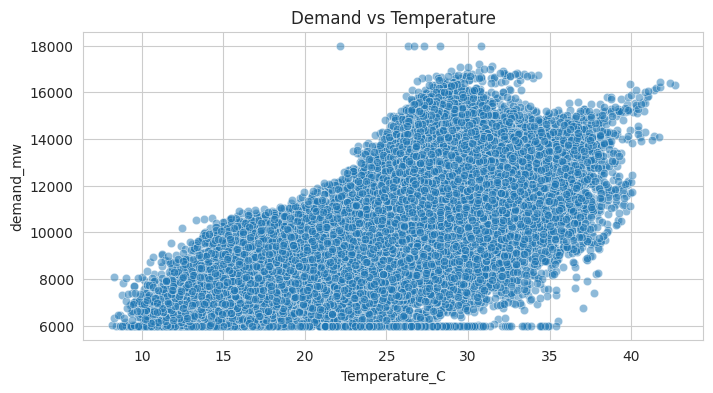

In [37]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x="Temperature_C",y="demand_mw",alpha=0.5)
plt.title("Demand vs Temperature")
plt.show()

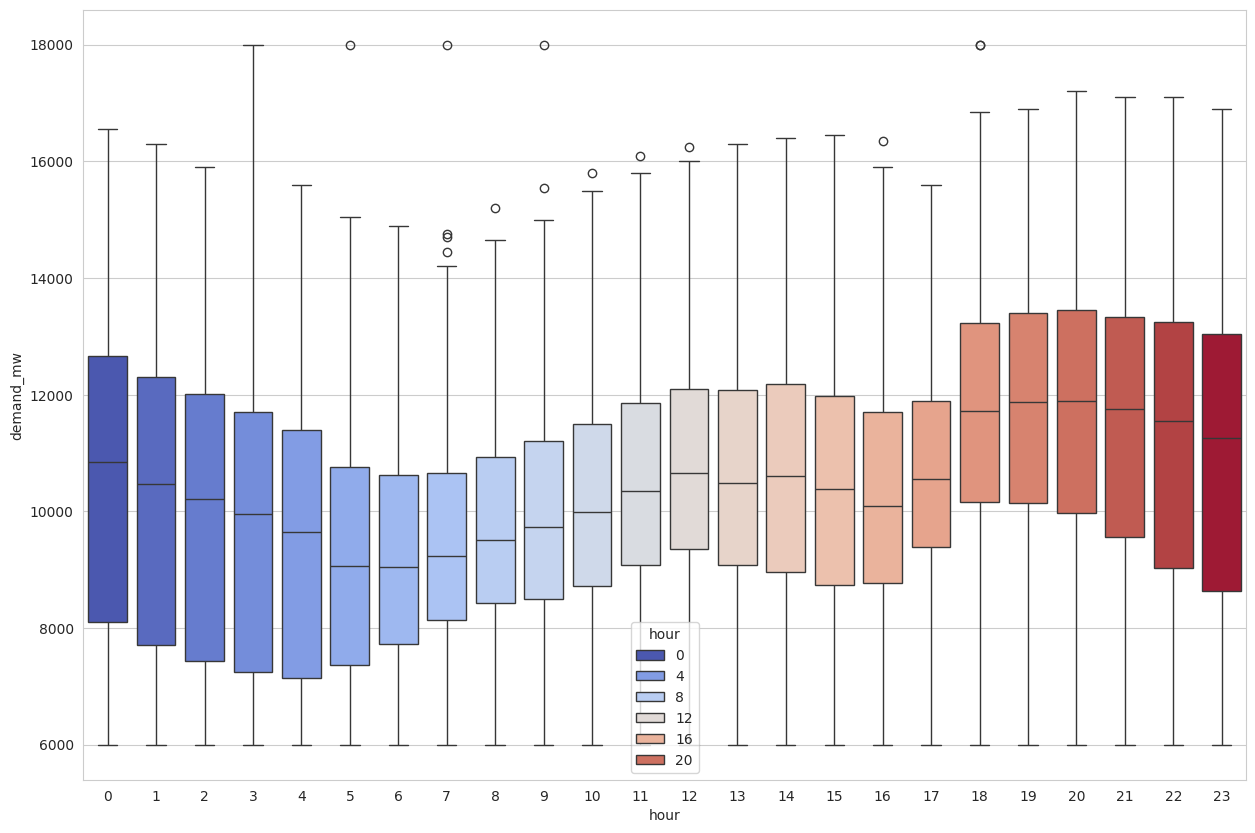

In [38]:
plt.figure(figsize=(15,10))
sns.boxplot(
    x="hour",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="hour",
    #showfliers=False
);


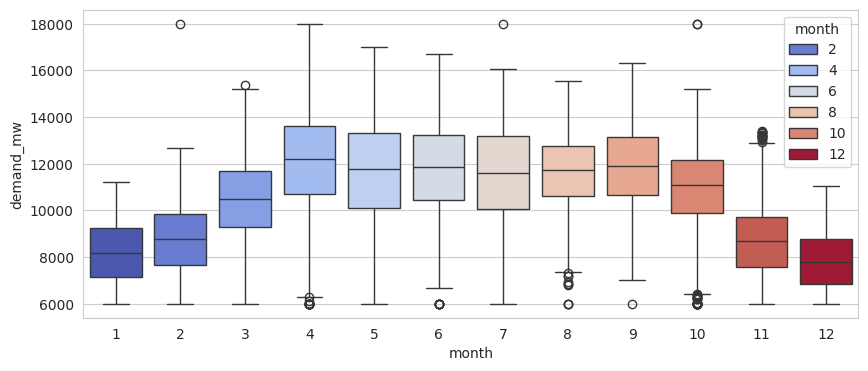

In [39]:
plt.figure(figsize=(10,4))
sns.boxplot(
    x="month",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="month",
    #showfliers=False
);


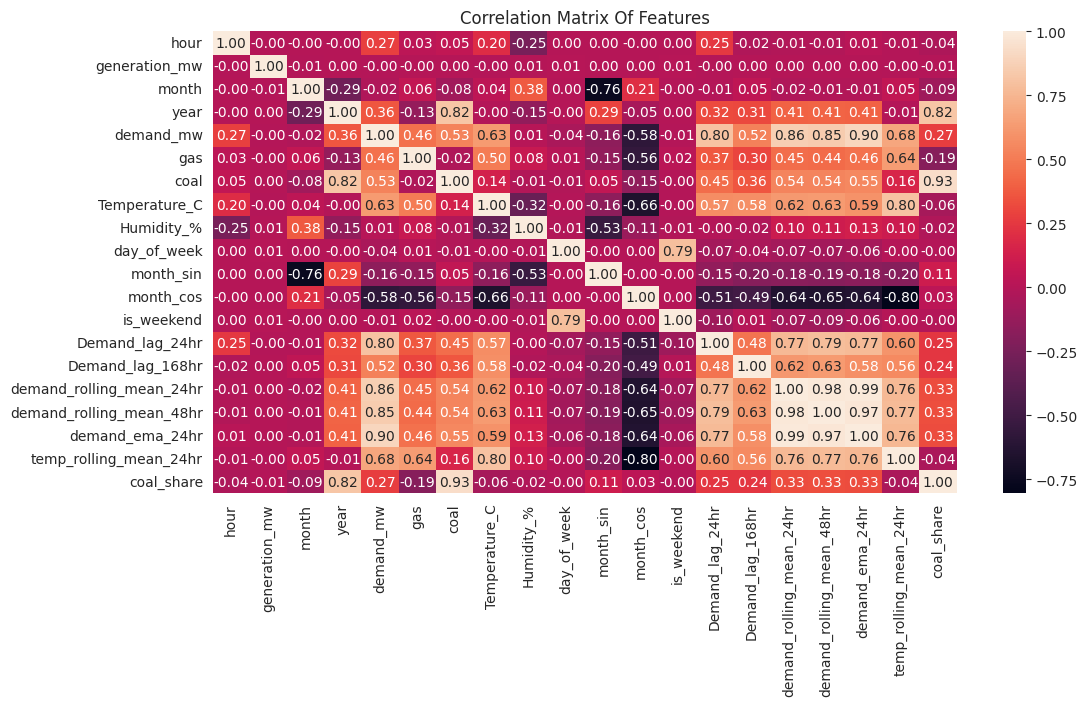

In [40]:
# correlation matrix
plt.figure(figsize=(12,6))
plt.title("Correlation Matrix Of Features")
sns.heatmap(df.corr(),annot=True,fmt=".2f");

In [41]:
#define target variable y
y=df.demand_mw # target variable/ dependent variable
print(y)

datetime
2020-06-23 18:00:00     9862
2020-06-23 18:30:00    11298
2020-06-23 19:00:00    11577
2020-06-23 20:00:00    11673
2020-06-23 21:00:00    11693
                       ...  
2025-06-17 08:00:00    11896
2025-06-17 09:00:00    12290
2025-06-17 10:00:00    12443
2025-06-17 11:00:00    12826
2025-06-17 12:00:00    13139
Name: demand_mw, Length: 45498, dtype: int64


In [42]:
#define Features(x)
x=df.drop("demand_mw",axis=1)  #indipendent variables/ features/predictors
x

,hour,generation_mw,month,year,gas,coal,Temperature_C,Humidity_%,day_of_week,month_sin,month_cos,is_weekend,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share
datetime,,,,,,,,,,,,,,,,,,,
2020-06-23 18:00:00,18,9862.0,6,2020,5640,149,28.82,92.670,1,1.224647e-16,-1.0,0,10939.0,10574.0,9978.833333,9748.583333,9668.077191,28.864583,0.015108
2020-06-23 18:30:00,18,11298.0,6,2020,6072,149,28.48,93.445,1,1.224647e-16,-1.0,0,11153.0,9974.0,9984.875000,9752.916667,9798.471016,28.891250,0.013188
2020-06-23 19:00:00,19,11577.0,6,2020,6024,149,28.14,94.220,1,1.224647e-16,-1.0,0,11476.0,9866.0,9989.083333,9767.520833,9940.753335,28.914167,0.012870
2020-06-23 20:00:00,20,11673.0,6,2020,6027,149,27.78,94.910,1,1.224647e-16,-1.0,0,11501.0,9538.0,9996.250000,9785.666667,10079.333068,28.932083,0.012764
2020-06-23 21:00:00,21,11693.0,6,2020,6030,149,27.50,95.630,1,1.224647e-16,-1.0,0,11465.0,9365.0,10005.750000,9806.541667,10208.426423,28.946667,0.012743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,87.730,1,1.224647e-16,-1.0,0,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,84.070,1,1.224647e-16,-1.0,0,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,81.710,1,1.224647e-16,-1.0,0,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400


In [43]:

train_size = int(len(x) * 0.70)
val_size   = int(len(x) * 0.15)

x_train = x.iloc[:train_size]
y_train = y.iloc[:train_size]

x_val = x.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]

x_test = x.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(x_train.shape, x_val.shape, x_test.shape)

(31848, 19) (6824, 19) (6826, 19)


In [44]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [45]:
sx = MinMaxScaler()
sy = MinMaxScaler()

x_train = sx.fit_transform(x_train)
x_val   = sx.transform(x_val)
x_test  = sx.transform(x_test)

y_train = sy.fit_transform(y_train.values.reshape(-1,1))
y_val   = sy.transform(y_val.values.reshape(-1,1))
y_test  = sy.transform(y_test.values.reshape(-1,1))

In [46]:
w = 24

def make_window(x, y, w):
    X, Y = [], []
    for i in range(len(x) - w):
        X.append(x[i:i+w])
        Y.append(y[i+w])
    return np.array(X), np.array(Y)

x_train_w, y_train_w = make_window(x_train, y_train, w)
x_val_w,   y_val_w   = make_window(x_val, y_val, w)
x_test_w,  y_test_w  = make_window(x_test, y_test, w)

print("Train:", x_train_w.shape, y_train_w.shape)
print("Val  :", x_val_w.shape, y_val_w.shape)
print("Test :", x_test_w.shape, y_test_w.shape)

Train: (31824, 24, 19) (31824, 1)
Val  : (6800, 24, 19) (6800, 1)
Test : (6802, 24, 19) (6802, 1)


In [47]:
x_train_t = torch.tensor(x_train_w, dtype=torch.float32)
y_train_t = torch.tensor(y_train_w, dtype=torch.float32)

x_val_t = torch.tensor(x_val_w, dtype=torch.float32)
y_val_t = torch.tensor(y_val_w, dtype=torch.float32)

x_test_t = torch.tensor(x_test_w, dtype=torch.float32)
y_test_t = torch.tensor(y_test_w, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=32, shuffle=False)

In [48]:
class CNN1D(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3),
            nn.ReLU(),

            nn.Conv1d(64, 32, kernel_size=3),
            nn.ReLU(),

            nn.AdaptiveMaxPool1d(1)
        )

        self.bn = nn.BatchNorm1d(32)
        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.squeeze(-1)
        x = self.bn(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = CNN1D(x_train_w.shape[2])

In [49]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [50]:
import time

epochs = 50

train_loss_list = []
val_loss_list = []

start_time = time.time()   #  start

print_step = 5   # every 5 epoch

for epoch in range(epochs):
    epoch_start = time.time()

    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # VALIDATION
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    #  print every 5 epoch
    if (epoch + 1) % print_step == 0:
        print(f"{epoch+1}/50 | Train: {train_loss:.6f} | Val: {val_loss:.6f} | Time: {time.time()-epoch_start:.2f}s")

#  TOTAL TIME
total_time = time.time() - start_time
print(f"\nTOTAL TRAINING TIME: {total_time:.2f} sec")

5/50 | Train: 0.005824 | Val: 0.007870 | Time: 4.70s
10/50 | Train: 0.004711 | Val: 0.007881 | Time: 5.83s
15/50 | Train: 0.004267 | Val: 0.012832 | Time: 4.44s
20/50 | Train: 0.004124 | Val: 0.018496 | Time: 4.43s
25/50 | Train: 0.003836 | Val: 0.010173 | Time: 5.35s
30/50 | Train: 0.003613 | Val: 0.015136 | Time: 4.31s
35/50 | Train: 0.003480 | Val: 0.006392 | Time: 5.35s
40/50 | Train: 0.003214 | Val: 0.006367 | Time: 4.57s
45/50 | Train: 0.003281 | Val: 0.007953 | Time: 4.39s
50/50 | Train: 0.003141 | Val: 0.005537 | Time: 5.83s

TOTAL TRAINING TIME: 244.57 sec


In [51]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [52]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1))
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1))

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

eps = 1e-8
mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + eps))) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

MSE : 472306.28019016836
RMSE: 687.2454293701547
MAE : 527.1684008236318
MAPE: 4.570211738349688
R2  : 0.9020478720564391


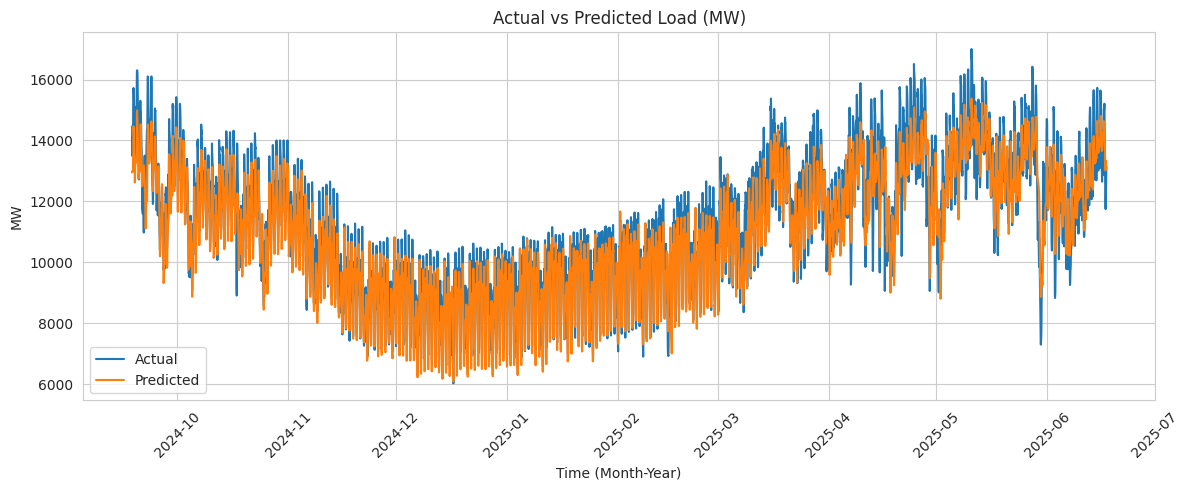

In [54]:
import pandas as pd

# time index fix (IMPORTANT)
time_index = y.index[-len(y_true_inv):]

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv, label="Actual")
plt.plot(time_index, y_pred_inv, label="Predicted")

plt.title("Actual vs Predicted Load (MW)")
plt.xlabel("Time (Month-Year)")
plt.ylabel("MW")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

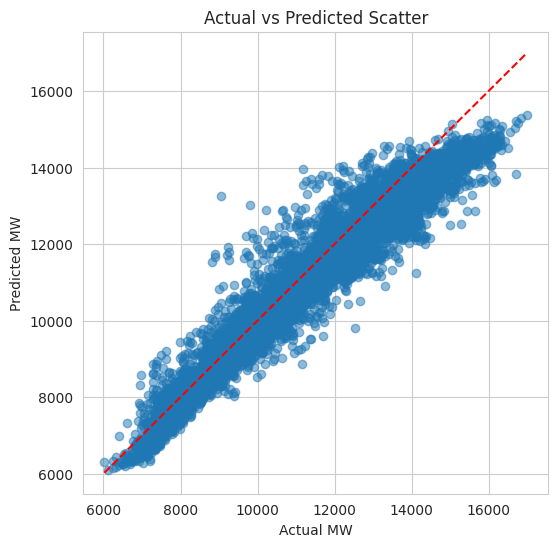

In [55]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.title("Actual vs Predicted Scatter")

# perfect line
plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.show()

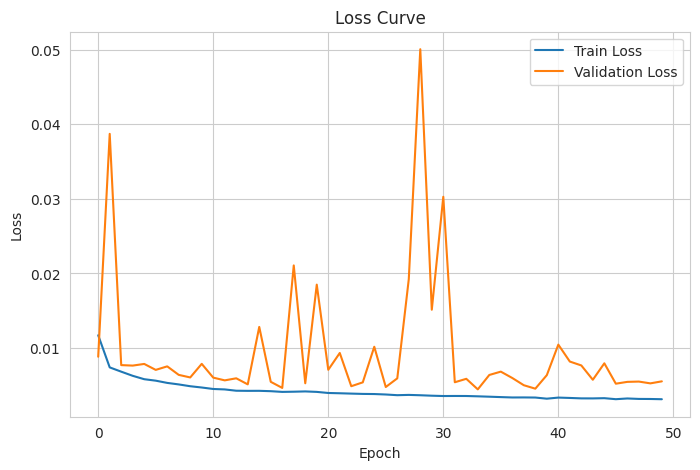

In [56]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

#LSTM

In [57]:

class LSTMModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=64,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last timestep
        out = self.dropout(out)
        out = self.fc(out)
        return out


model = LSTMModel(x_train_w.shape[2])

In [59]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [60]:

epochs = 50
train_loss_list = []
val_loss_list = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if (epoch+1) % 5 == 0:
        print(f"{epoch+1}/50 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

print("\nTOTAL TIME:", time.time() - start_time, "sec")

5/50 | Train: 0.002567 | Val: 0.004620
10/50 | Train: 0.001735 | Val: 0.002979
15/50 | Train: 0.001433 | Val: 0.002366
20/50 | Train: 0.001287 | Val: 0.002102
25/50 | Train: 0.001213 | Val: 0.002782
30/50 | Train: 0.001146 | Val: 0.001995
35/50 | Train: 0.001083 | Val: 0.002233
40/50 | Train: 0.001040 | Val: 0.001731
45/50 | Train: 0.001006 | Val: 0.001772
50/50 | Train: 0.000948 | Val: 0.001780

TOTAL TIME: 243.54368090629578 sec


In [61]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [62]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

In [63]:

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

eps = 1e-8
mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + eps))) * 100

print("LSTM PERFORMANCE")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

LSTM PERFORMANCE
MSE : 124557.8614603674
RMSE: 352.92755837475687
MAE : 259.42468997514516
MAPE: 2.2934391251431077
R2  : 0.9741678057356558


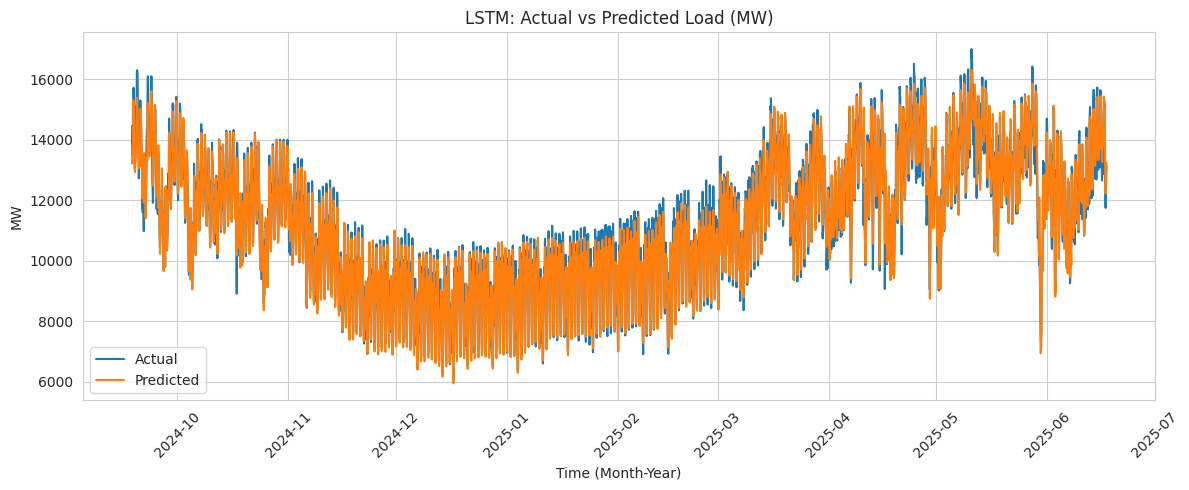

In [64]:
import matplotlib.pyplot as plt

time_index = y.iloc[train_size + val_size + w:].index

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv, label="Actual")
plt.plot(time_index, y_pred_inv, label="Predicted")

plt.title("LSTM: Actual vs Predicted Load (MW)")
plt.xlabel("Time (Month-Year)")
plt.ylabel("MW")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

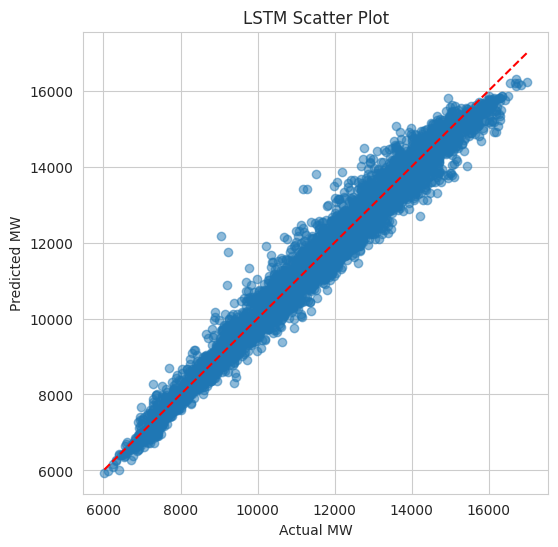

In [65]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.title("LSTM Scatter Plot")

plt.show()

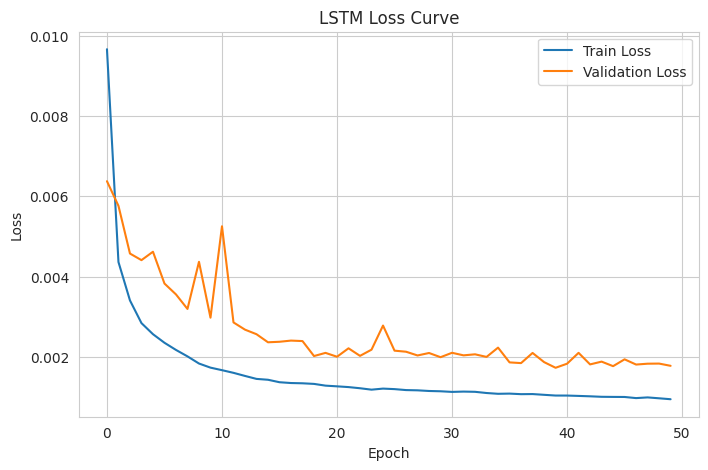

In [66]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

#CNN-BiLSTM Attention Hybried Model

In [67]:
import torch
import torch.nn as nn

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, time, hidden)
        weights = torch.softmax(self.attn(x), dim=1)   # (batch, time, 1)
        context = torch.sum(weights * x, dim=1)         # (batch, hidden)
        return context

In [68]:
class HybridModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN branch
        self.cnn = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3),
            nn.ReLU(),
            nn.AdaptiveMaxPool1d(1)
        )
        self.cnn_dropout = nn.Dropout(0.2)

        # BiLSTM branch
        self.lstm = nn.LSTM(
            input_size=input_features,
            hidden_size=64,
            batch_first=True,
            bidirectional=True
        )
        self.attn = Attention(128)

        # Final
        self.bn = nn.BatchNorm1d(32 + 128)

        self.fc = nn.Sequential(
            nn.Linear(160, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # CNN branch
        x_cnn = x.permute(0,2,1)
        x_cnn = self.cnn(x_cnn).squeeze(-1)
        x_cnn = self.cnn_dropout(x_cnn)

        # LSTM branch
        x_lstm, _ = self.lstm(x)
        x_lstm = self.attn(x_lstm)

        # concat
        x = torch.cat((x_cnn, x_lstm), dim=1)
        x = self.bn(x)
        x = self.fc(x)

        return x


model = HybridModel(x_train_w.shape[2])

In [69]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [70]:
import time

epochs = 50
train_loss_list = []
val_loss_list = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if (epoch+1) % 5 == 0:
        print(f"{epoch+1}/50 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

print("\nTOTAL TIME:", time.time() - start_time)

5/50 | Train: 0.003144 | Val: 0.006220
10/50 | Train: 0.001960 | Val: 0.003073
15/50 | Train: 0.001573 | Val: 0.002524
20/50 | Train: 0.001417 | Val: 0.002074
25/50 | Train: 0.001244 | Val: 0.002666
30/50 | Train: 0.001197 | Val: 0.002829
35/50 | Train: 0.001093 | Val: 0.002625
40/50 | Train: 0.001020 | Val: 0.002178
45/50 | Train: 0.000933 | Val: 0.002629
50/50 | Train: 0.000917 | Val: 0.002306

TOTAL TIME: 631.626344203949


In [71]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [72]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv+1e-8))) * 100

print("===== HYBRID PERFORMANCE =====")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

===== HYBRID PERFORMANCE =====
MSE : 116837.17462109482
RMSE: 341.8145324896161
MAE : 254.66995216825015
MAPE: 2.3023395182367237
R2  : 0.9757690076184427


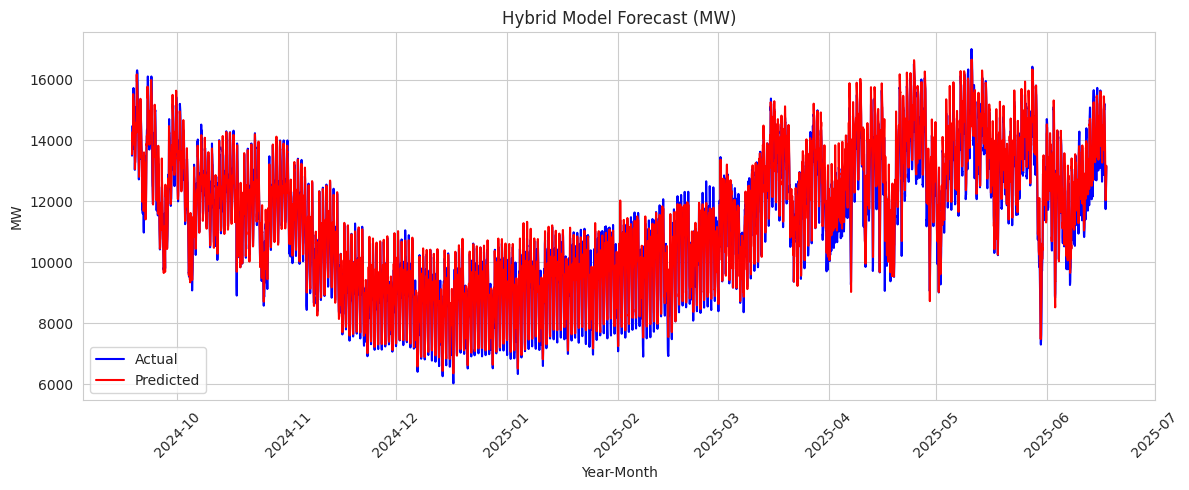

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

# correct time index
time_index = y.iloc[train_size + val_size + w:].index

# convert to Year-Month format
time_index = pd.to_datetime(time_index)

plt.figure(figsize=(12,5))

plt.plot(time_index, y_true_inv, color='blue', label="Actual")

plt.plot(time_index, y_pred_inv, color='red', label="Predicted")

plt.title("Hybrid Model Forecast (MW)")
plt.xlabel("Year-Month")
plt.ylabel("MW")

# format x-axis as Year-Month
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_660/3827728119.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_plot.resample("M").mean()


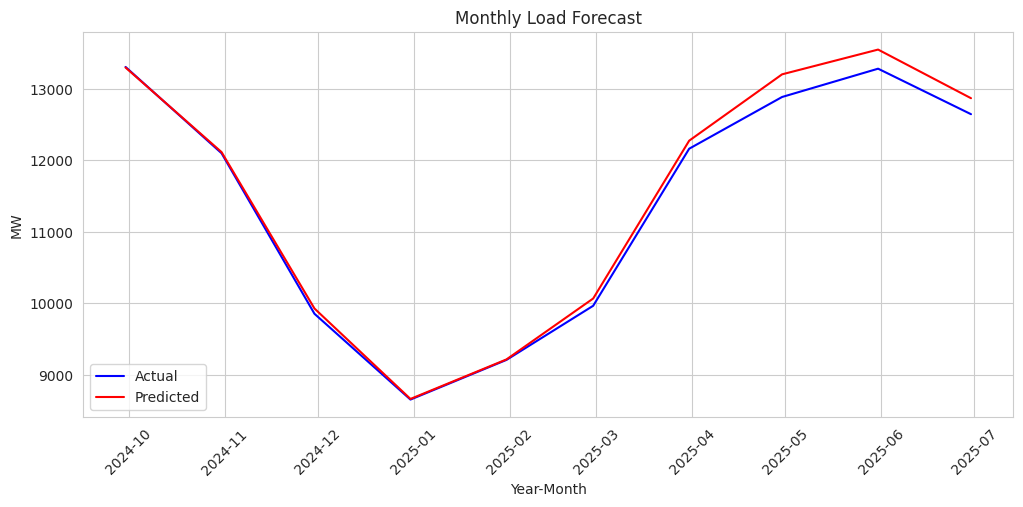

In [80]:
df_plot = pd.DataFrame({
    "Actual": y_true_inv,
    "Predicted": y_pred_inv
}, index=time_index)

df_monthly = df_plot.resample("M").mean()

plt.figure(figsize=(12,5))
plt.plot(df_monthly.index, df_monthly["Actual"], color='blue', label="Actual")
plt.plot(df_monthly.index, df_monthly["Predicted"], color='red', label="Predicted")

plt.title("Monthly Load Forecast")
plt.xlabel("Year-Month")
plt.ylabel("MW")
plt.legend()
plt.xticks(rotation=45)
plt.show()

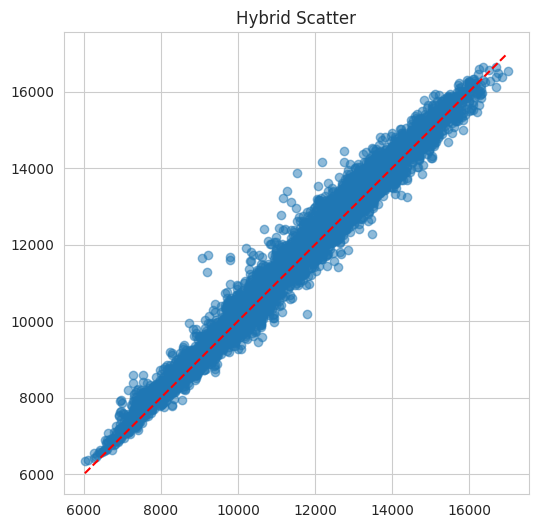

In [75]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.title("Hybrid Scatter")
plt.show()

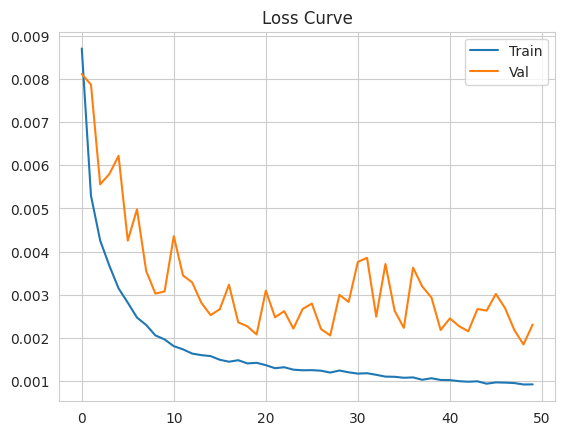

In [76]:
plt.plot(train_loss_list, label="Train")
plt.plot(val_loss_list, label="Val")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [81]:
import torch
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN
        self.conv1 = nn.Conv1d(input_features, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=64,
            batch_first=True
        )

        self.bn = nn.BatchNorm1d(64)

        # Dense
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, time, features)

        # CNN expects (batch, features, time)
        x = x.permute(0,2,1)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))

        x = self.dropout(x)

        # back to (batch, time, features)
        x = x.permute(0,2,1)

        # LSTM
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last timestep

        out = self.bn(out)
        out = self.fc(out)

        return out


model = CNN_LSTM(x_train_w.shape[2])

In [82]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [83]:
import time

epochs = 50
train_loss_list = []
val_loss_list = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if (epoch+1) % 5 == 0:
        print(f"{epoch+1}/50 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

print("\nTOTAL TIME:", time.time() - start_time)

5/50 | Train: 0.003116 | Val: 0.005062
10/50 | Train: 0.002214 | Val: 0.004416
15/50 | Train: 0.001866 | Val: 0.003930
20/50 | Train: 0.001625 | Val: 0.002949
25/50 | Train: 0.001502 | Val: 0.003288
30/50 | Train: 0.001436 | Val: 0.003182
35/50 | Train: 0.001346 | Val: 0.003361
40/50 | Train: 0.001302 | Val: 0.002781
45/50 | Train: 0.001260 | Val: 0.004248
50/50 | Train: 0.001192 | Val: 0.005070

TOTAL TIME: 473.5693883895874


In [84]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [85]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv+1e-8))) * 100

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

MSE : 635445.2551245564
RMSE: 797.1482014811024
MAE : 650.612977599649
MAPE: 5.501898895625632
R2  : 0.8682142974977428


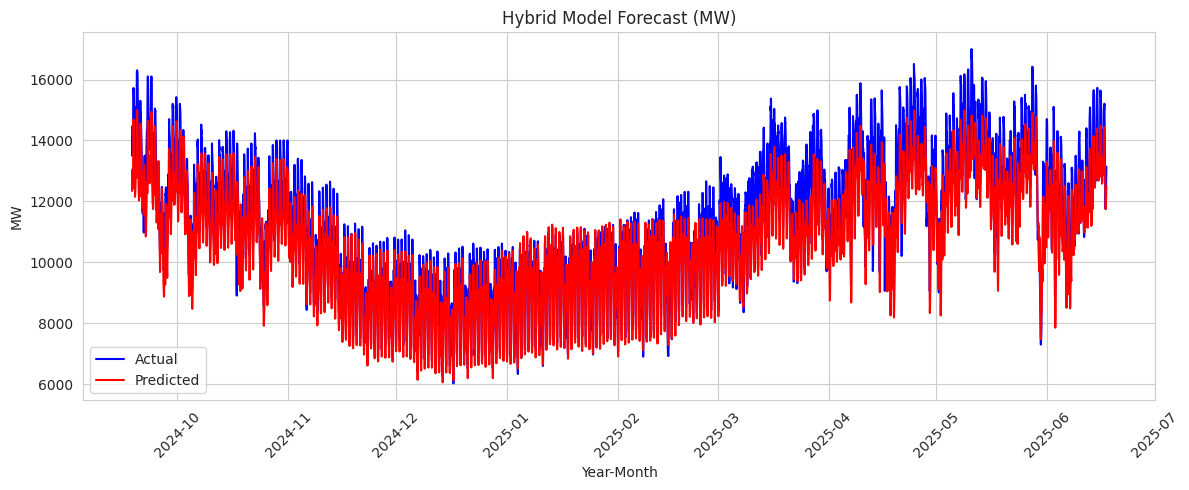

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# correct time index
time_index = y.iloc[train_size + val_size + w:].index

# convert to Year-Month format
time_index = pd.to_datetime(time_index)

plt.figure(figsize=(12,5))

#  Actual = BLUE
plt.plot(time_index, y_true_inv, color='blue', label="Actual")

#  Predicted = RED
plt.plot(time_index, y_pred_inv, color='red', label="Predicted")

plt.title("Hybrid Model Forecast (MW)")
plt.xlabel("Year-Month")
plt.ylabel("MW")

# format x-axis as Year-Month
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_660/3827728119.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_plot.resample("M").mean()


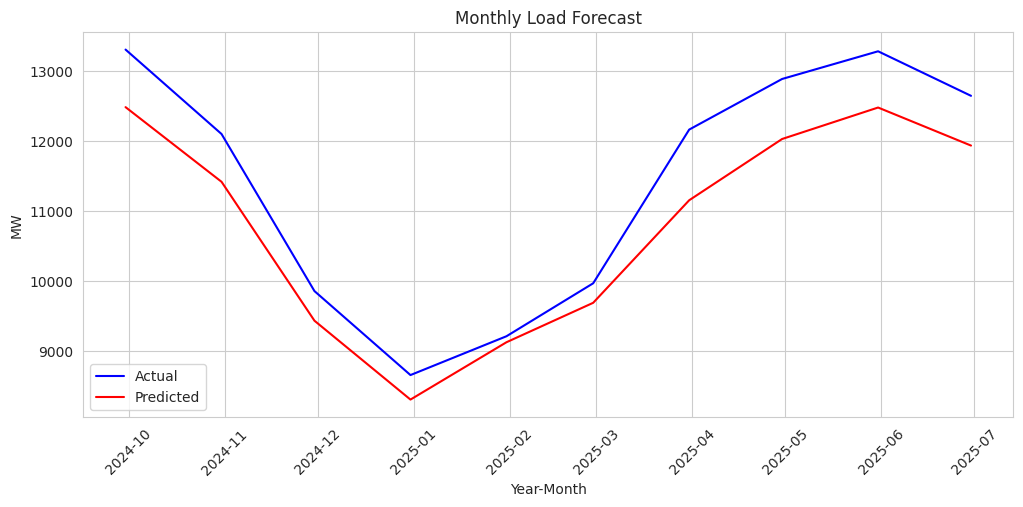

In [87]:
df_plot = pd.DataFrame({
    "Actual": y_true_inv,
    "Predicted": y_pred_inv
}, index=time_index)

df_monthly = df_plot.resample("M").mean()

plt.figure(figsize=(12,5))
plt.plot(df_monthly.index, df_monthly["Actual"], color='blue', label="Actual")
plt.plot(df_monthly.index, df_monthly["Predicted"], color='red', label="Predicted")

plt.title("Monthly Load Forecast")
plt.xlabel("Year-Month")
plt.ylabel("MW")
plt.legend()
plt.xticks(rotation=45)
plt.show()

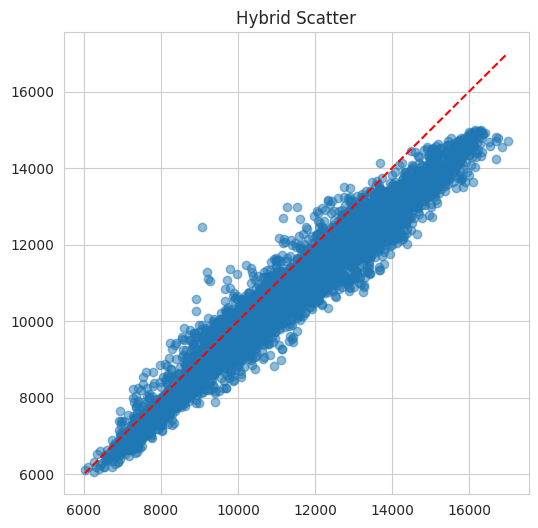

In [88]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.title("Hybrid Scatter")
plt.show()

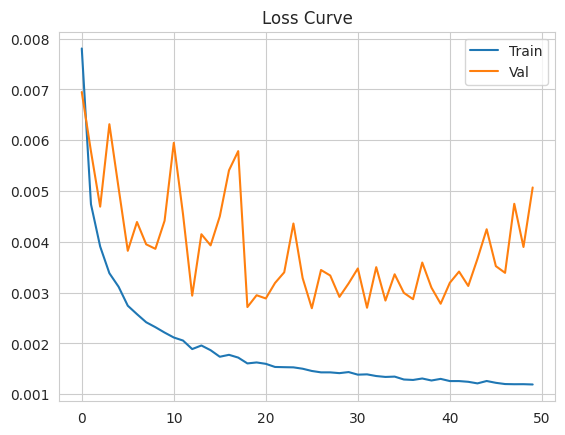

In [89]:
plt.plot(train_loss_list, label="Train")
plt.plot(val_loss_list, label="Val")
plt.legend()
plt.title("Loss Curve")
plt.show()

In [90]:
import torch
import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_features,
            hidden_size=64,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]   # last timestep
        out = self.dropout(out)
        out = self.fc(out)
        return out


model = GRUModel(x_train_w.shape[2])

In [91]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [92]:
import time

epochs = 50
train_loss_list = []
val_loss_list = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"{epoch+1}/50 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

print("\nTOTAL TIME:", time.time() - start_time, "sec")

5/50 | Train: 0.002390 | Val: 0.004257
10/50 | Train: 0.001542 | Val: 0.002359
15/50 | Train: 0.001345 | Val: 0.002299
20/50 | Train: 0.001236 | Val: 0.002037
25/50 | Train: 0.001153 | Val: 0.001921
30/50 | Train: 0.001101 | Val: 0.001766
35/50 | Train: 0.001064 | Val: 0.001791
40/50 | Train: 0.001022 | Val: 0.001887
45/50 | Train: 0.000993 | Val: 0.001971
50/50 | Train: 0.000957 | Val: 0.001853

TOTAL TIME: 694.8806612491608 sec


In [93]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [94]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

In [95]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

eps = 1e-8
mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv + eps))) * 100

print("===== GRU PERFORMANCE =====")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

===== GRU PERFORMANCE =====
MSE : 126307.69106303909
RMSE: 355.3979333972541
MAE : 270.15867295751707
MAPE: 2.361797534835699
R2  : 0.9738049066163569


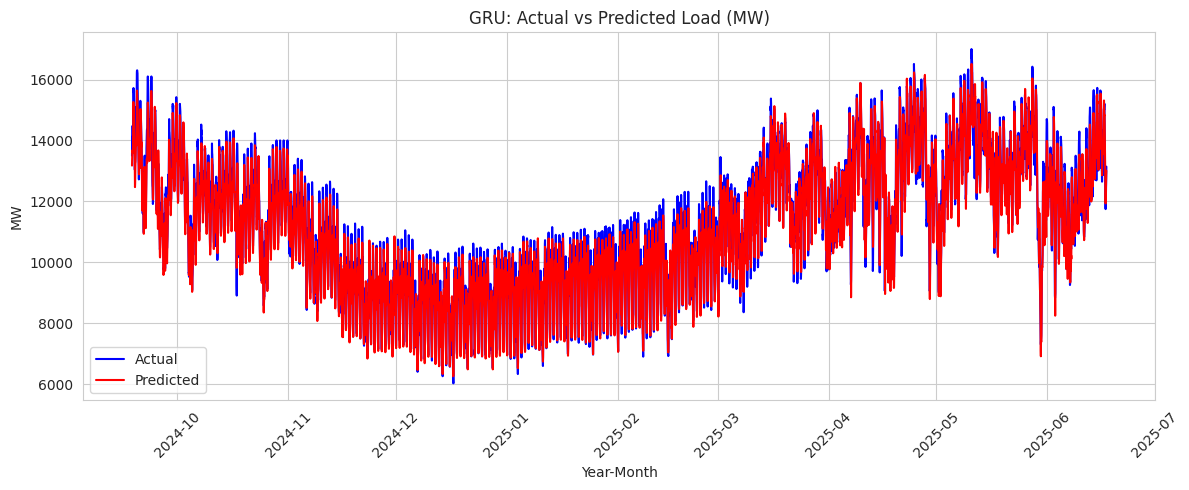

In [96]:
import matplotlib.pyplot as plt

time_index = y.iloc[train_size + val_size + w:].index

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv, color='blue', label="Actual")
plt.plot(time_index, y_pred_inv, color='red', label="Predicted")

plt.title("GRU: Actual vs Predicted Load (MW)")
plt.xlabel("Year-Month")
plt.ylabel("MW")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

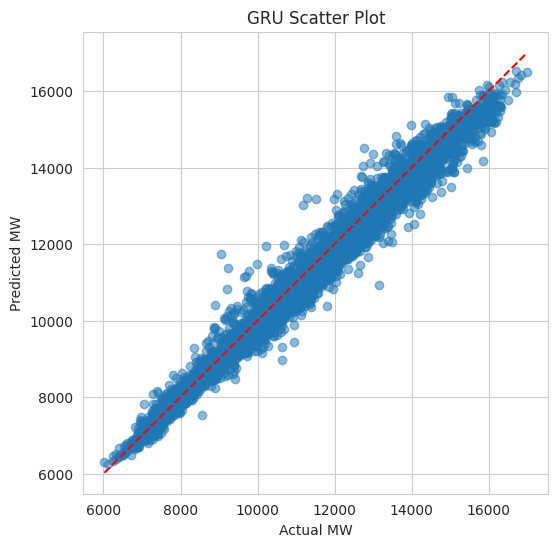

In [97]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.title("GRU Scatter Plot")
plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.show()

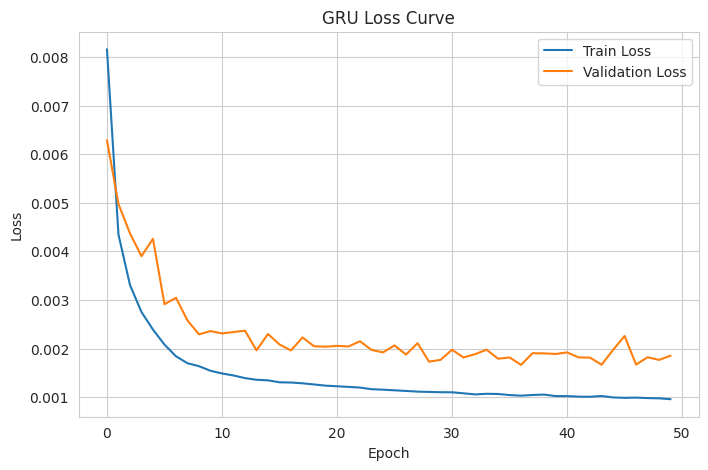

In [98]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("GRU Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [105]:
import torch
import torch.nn as nn

class CNN_BiLSTM(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        # CNN Branch
        self.conv = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout_cnn = nn.Dropout(0.2)

        # BiLSTM Branch
        self.bilstm = nn.LSTM(
            input_size=input_features,
            hidden_size=64,
            batch_first=True,
            bidirectional=True
        )

        self.dropout_lstm = nn.Dropout(0.2)

        # Final
        self.bn = nn.BatchNorm1d(32 + 128)

        self.fc = nn.Sequential(
            nn.Linear(160, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, time, features)

        # CNN branch
        x_cnn = x.permute(0, 2, 1)
        x_cnn = self.conv(x_cnn)
        x_cnn = self.pool(x_cnn).squeeze(-1)
        x_cnn = self.dropout_cnn(x_cnn)

        # BiLSTM branch
        x_lstm, _ = self.bilstm(x)
        x_lstm = x_lstm[:, -1, :]
        x_lstm = self.dropout_lstm(x_lstm)

        # concatenate
        x = torch.cat((x_cnn, x_lstm), dim=1)
        x = self.bn(x)

        x = self.fc(x)

        return x


model = CNN_BiLSTM(x_train_w.shape[2])

In [106]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time

epochs = 50
train_loss_list = []
val_loss_list = []

start_time = time.time()

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if (epoch+1) % 5 == 0:
        print(f"{epoch+1}/50 | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

print("\nTOTAL TIME:", time.time() - start_time)

5/50 | Train: 0.002979 | Val: 0.004299
10/50 | Train: 0.002304 | Val: 0.003172


In [ ]:
model.eval()
pred = []

with torch.no_grad():
    for xb, _ in test_loader:
        pred.append(model(xb).cpu().numpy())

y_pred = np.concatenate(pred).reshape(-1)
y_true = y_test_w.reshape(-1)

In [ ]:
y_true_inv = sy.inverse_transform(y_true.reshape(-1,1)).reshape(-1)
y_pred_inv = sy.inverse_transform(y_pred.reshape(-1,1)).reshape(-1)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_true_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_inv, y_pred_inv)
r2 = r2_score(y_true_inv, y_pred_inv)

mape = np.mean(np.abs((y_true_inv - y_pred_inv)/(y_true_inv + 1e-8))) * 100

print("===== CNN-BiLSTM HYBRID =====")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("R2  :", r2)

In [ ]:
import matplotlib.pyplot as plt

time_index = y.iloc[train_size + val_size + w:].index

plt.figure(figsize=(12,5))
plt.plot(time_index, y_true_inv, color='blue', label="Actual")
plt.plot(time_index, y_pred_inv, color='red', label="Predicted")

plt.title("CNN-BiLSTM Forecast (MW)")
plt.xlabel("Year-Month")
plt.ylabel("MW")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_true_inv, y_pred_inv, alpha=0.5)

plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()],
         'r--')

plt.title("CNN-BiLSTM Scatter Plot")
plt.xlabel("Actual MW")
plt.ylabel("Predicted MW")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")

plt.title("CNN-BiLSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()